# 第四阶段 B-2：主动数据聚合与 ANN v2

## 研究问题

阶段4A的ANN离线误差很小，但在Chen2020 DFN闭环中约13.0%的控制步需要安全层做超过0.1 A的实质修正，而且充电需要55.67 min。能否用4B-1的新混合教师重新标注ANN实际访问的状态，使第二版小型ANN同时接近教师速度并降低对安全层的实质依赖？

硬门槛包括：物理约束全部满足、实质介入不超过5%、平均修正不超过0.05 A、相对教师时间差不超过3%，且必须快于ANN v1。

## 输入、DAgger和加权损失

五个输入保持不变：

\[
x_k=[z_k,v_{f,k},v_{s,k},T_k,I_{k-1}]^{\mathsf T}.
\]

每一轮把当前策略访问的状态交给混合教师重新标注：

\[
\mathcal D_{r+1}=\mathcal D_r\cup
\{(x_k,\pi_{teacher}(x_k)):x_k\sim\pi_{\theta_r}\}.
\]

最终网络为 `5-16-16-1`，385个参数。普通训练状态权重为1，两轮在策略状态权重为3；验证和测试样本始终等权且保持冻结。

## 为什么要看修正幅度

二元介入标记会把毫安级数值修正和超过1 A的修正同等计数。本阶段定义

\[
\Delta I_k^{filter}=|\hat I_k-I_k^{safe}|,
\]

并把 \(\Delta I_k^{filter}>0.1\ \mathrm A\) 记为实质介入。安全过滤器仍保留，不因介入减少而删除。

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs" / "phase4b2.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

from battery_fast_charge.phase4b2_config import load_phase_four_b2_config
from battery_fast_charge.phase4b2_runner import run_phase_four_b2

config = load_phase_four_b2_config(PROJECT_ROOT / "configs" / "phase4b2.yaml")
print(f"研究：{config.study_name}")
print(f"最终隐藏层：{config.final_network.hidden_layer_sizes}")
print(f"在策略训练权重：{config.final_network.on_policy_training_weight}")

研究：chen2020_phase4b2_active_data_aggregation
最终隐藏层：(16, 16)
在策略训练权重：3.0


## 运行或读取正式结果

默认读取正式产物。将 `RUN_PHASE4B2` 改成 `True` 会重新求解教师标签、训练三轮网络并运行两条Chen2020 DFN轨迹，通常需要数分钟。

In [2]:
RUN_PHASE4B2 = False

metrics_path = PROJECT_ROOT / "outputs" / "metrics" / "phase4b2_metrics.json"
dataset_path = PROJECT_ROOT / "data" / "phase4b2" / "active_teacher_dataset.csv"
comparison_path = PROJECT_ROOT / "outputs" / "metrics" / "phase4b2_controller_comparison.csv"

if RUN_PHASE4B2 or any(not p.exists() for p in [metrics_path, dataset_path, comparison_path]):
    run_phase_four_b2(config, PROJECT_ROOT)

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
dataset = pd.read_csv(dataset_path)
comparison = pd.read_csv(comparison_path)

## 唯一状态、来源和混合教师模式

In [3]:
data_summary = pd.Series({
    "candidate states": metrics["active_dataset"]["candidate_count"],
    "accepted unique labels": metrics["active_dataset"]["accepted_count"],
    "teacher acceptance [%]": 100 * metrics["active_dataset"]["teacher_acceptance_fraction"],
    "duplicate feature rows": metrics["active_dataset"]["duplicate_feature_row_count"],
})
display(data_summary.to_frame("result"))
display(pd.Series(metrics["active_dataset"]["split_counts"], name="samples").to_frame())
display(pd.Series(metrics["active_dataset"]["source_counts"], name="samples").to_frame())
display(pd.Series(metrics["active_dataset"]["teacher_mode_counts"], name="samples").to_frame())

,result
candidate states,489.000000
accepted unique labels,486.000000
teacher acceptance [%],99.386503
duplicate feature rows,0.000000


,samples
train,364
validation,64
test,58


,samples
active_ann_rollout,208
legacy_relabelled,168
dagger_round_2,56
dagger_round_3_dfn,54


,samples
terminal_reference_governor,402
startup_reference_governor,44
thermal_budget_mpc,40


486个接受标签都是唯一五维状态。原168个状态已由新教师重标；随后加入旧ANN周围主动轨迹、降阶在策略轨迹和DFN在策略轨迹。三个教师模式均有样本，避免网络只看到终端5 A调节器。

## 主动覆盖扩展

,result
active_state_count,322.0000
mean_nearest_legacy_train_distance,0.9196
p95_nearest_legacy_train_distance,2.7027
maximum_nearest_legacy_train_distance,4.2069
fraction_beyond_unit_standardized_distance,0.3975


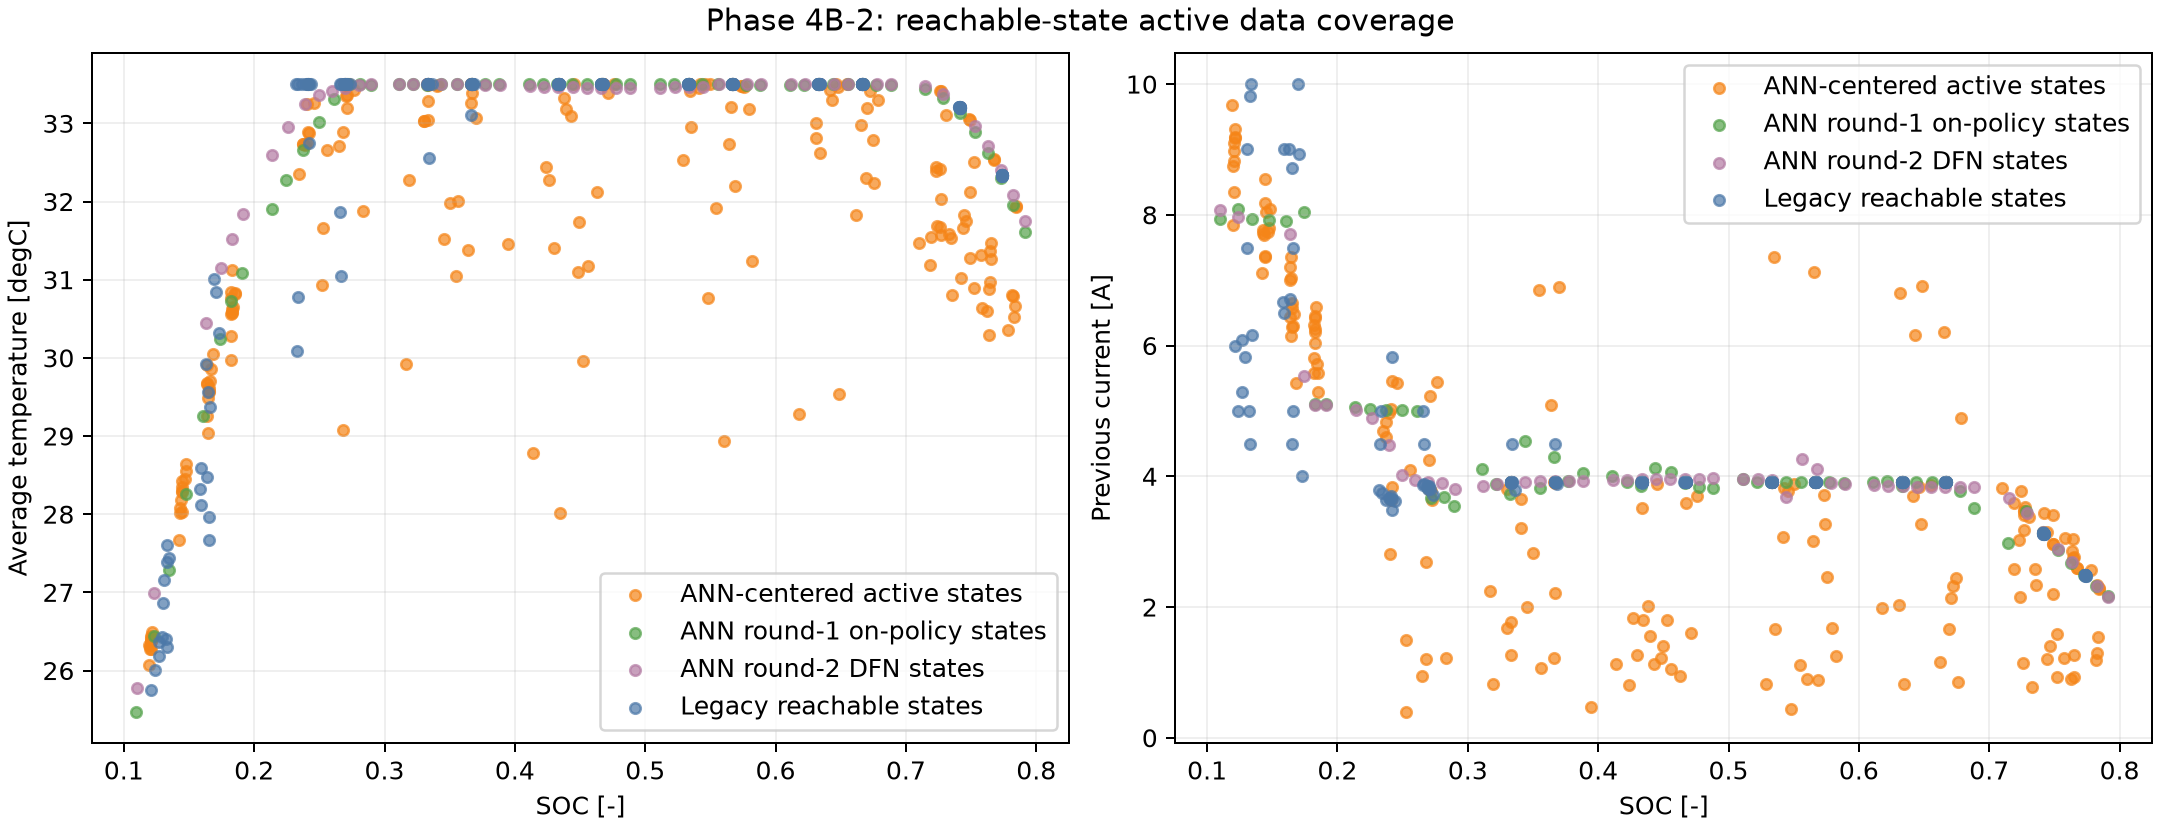

In [4]:
display(pd.Series(metrics["coverage_expansion"], name="result").to_frame().round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4b2_active_coverage.png")))

约40%的主动状态与旧训练集最近点的标准化距离超过1，说明新增数据并非只是在原样本附近机械重复。启动段和70%–80% SOC段被明确加密，因为旧ANN的最大分布距离和较大安全修正分别集中在那里。

## 三轮训练与最终离线结果

,round,architecture,parameters,test_MAE_A,test_RMSE_A
0,Round 1: old-ANN active data,5-8-8-1,129,0.1100,0.2127
1,Round 2: reduced-model DAgger,5-8-8-1,129,0.1344,0.2738
2,Final: DFN DAgger + weighting,5-16-16-1,385,0.2015,0.3679


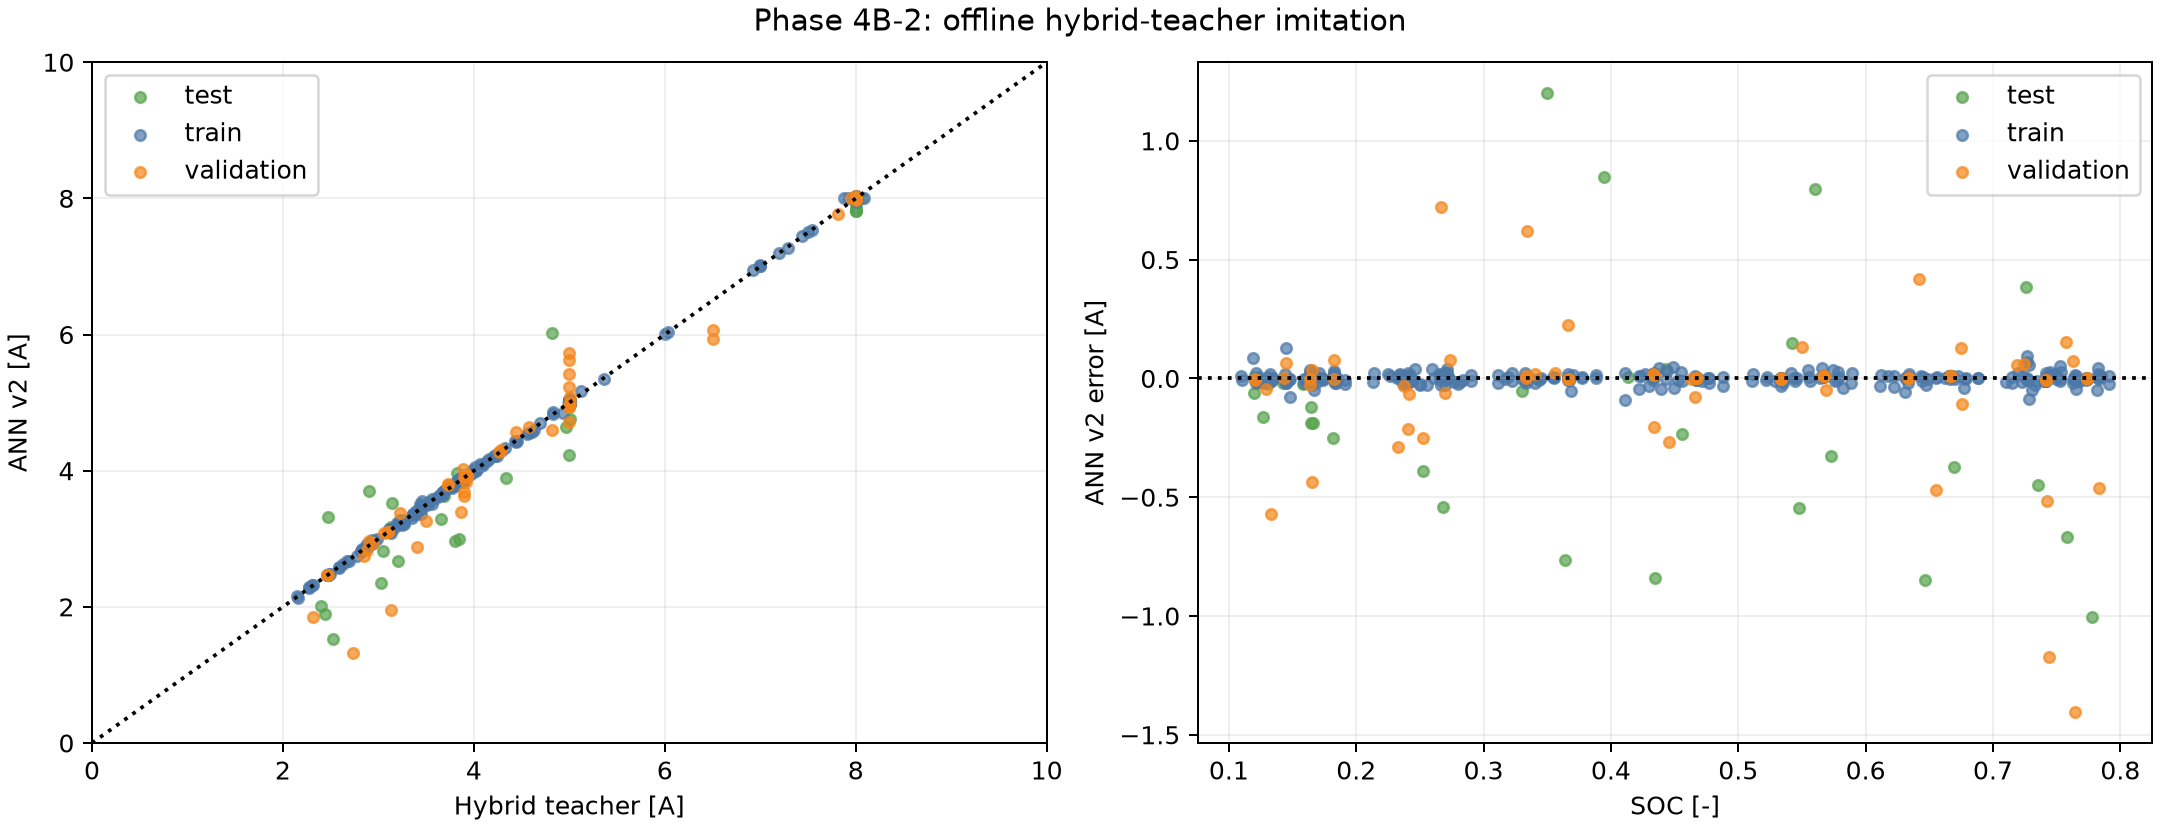

In [5]:
rounds = []
for name, key in [
    ("Round 1: old-ANN active data", "round1_offline_imitation"),
    ("Round 2: reduced-model DAgger", "round2_offline_imitation"),
    ("Final: DFN DAgger + weighting", "offline_imitation"),
]:
    item = metrics[key]
    test = item["split_metrics"]["test"]
    rounds.append({
        "round": name,
        "architecture": "-".join(map(str, item["architecture"])),
        "parameters": item["parameter_count"],
        "test_MAE_A": test["mae_a"],
        "test_RMSE_A": test["rmse_a"],
    })
display(pd.DataFrame(rounds).round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4b2_offline_imitation.png")))

最终测试MAE为0.2015 A、RMSE为0.3679 A，低于预先设置的0.35/0.50 A门槛。它高于阶段4A旧教师上的离线误差，但这里的标签包含三个控制模式和模型反馈差异；是否有效必须由闭环修正与时间共同判断。

## Chen2020 DFN：新旧ANN与教师

,controller,charge_time_min,material_intervention_fraction,mean_filter_correction_a,maximum_voltage_v,maximum_temperature_c,success
0,ANN v1 + safety filter,55.6667,0.1302,0.0610,4.1425,33.5012,True
1,Hybrid thermal-budget teacher,52.6667,0.0000,0.0000,4.1425,33.5024,True
2,ANN v2 + safety filter,52.7500,0.0158,0.0166,4.1426,33.5024,True


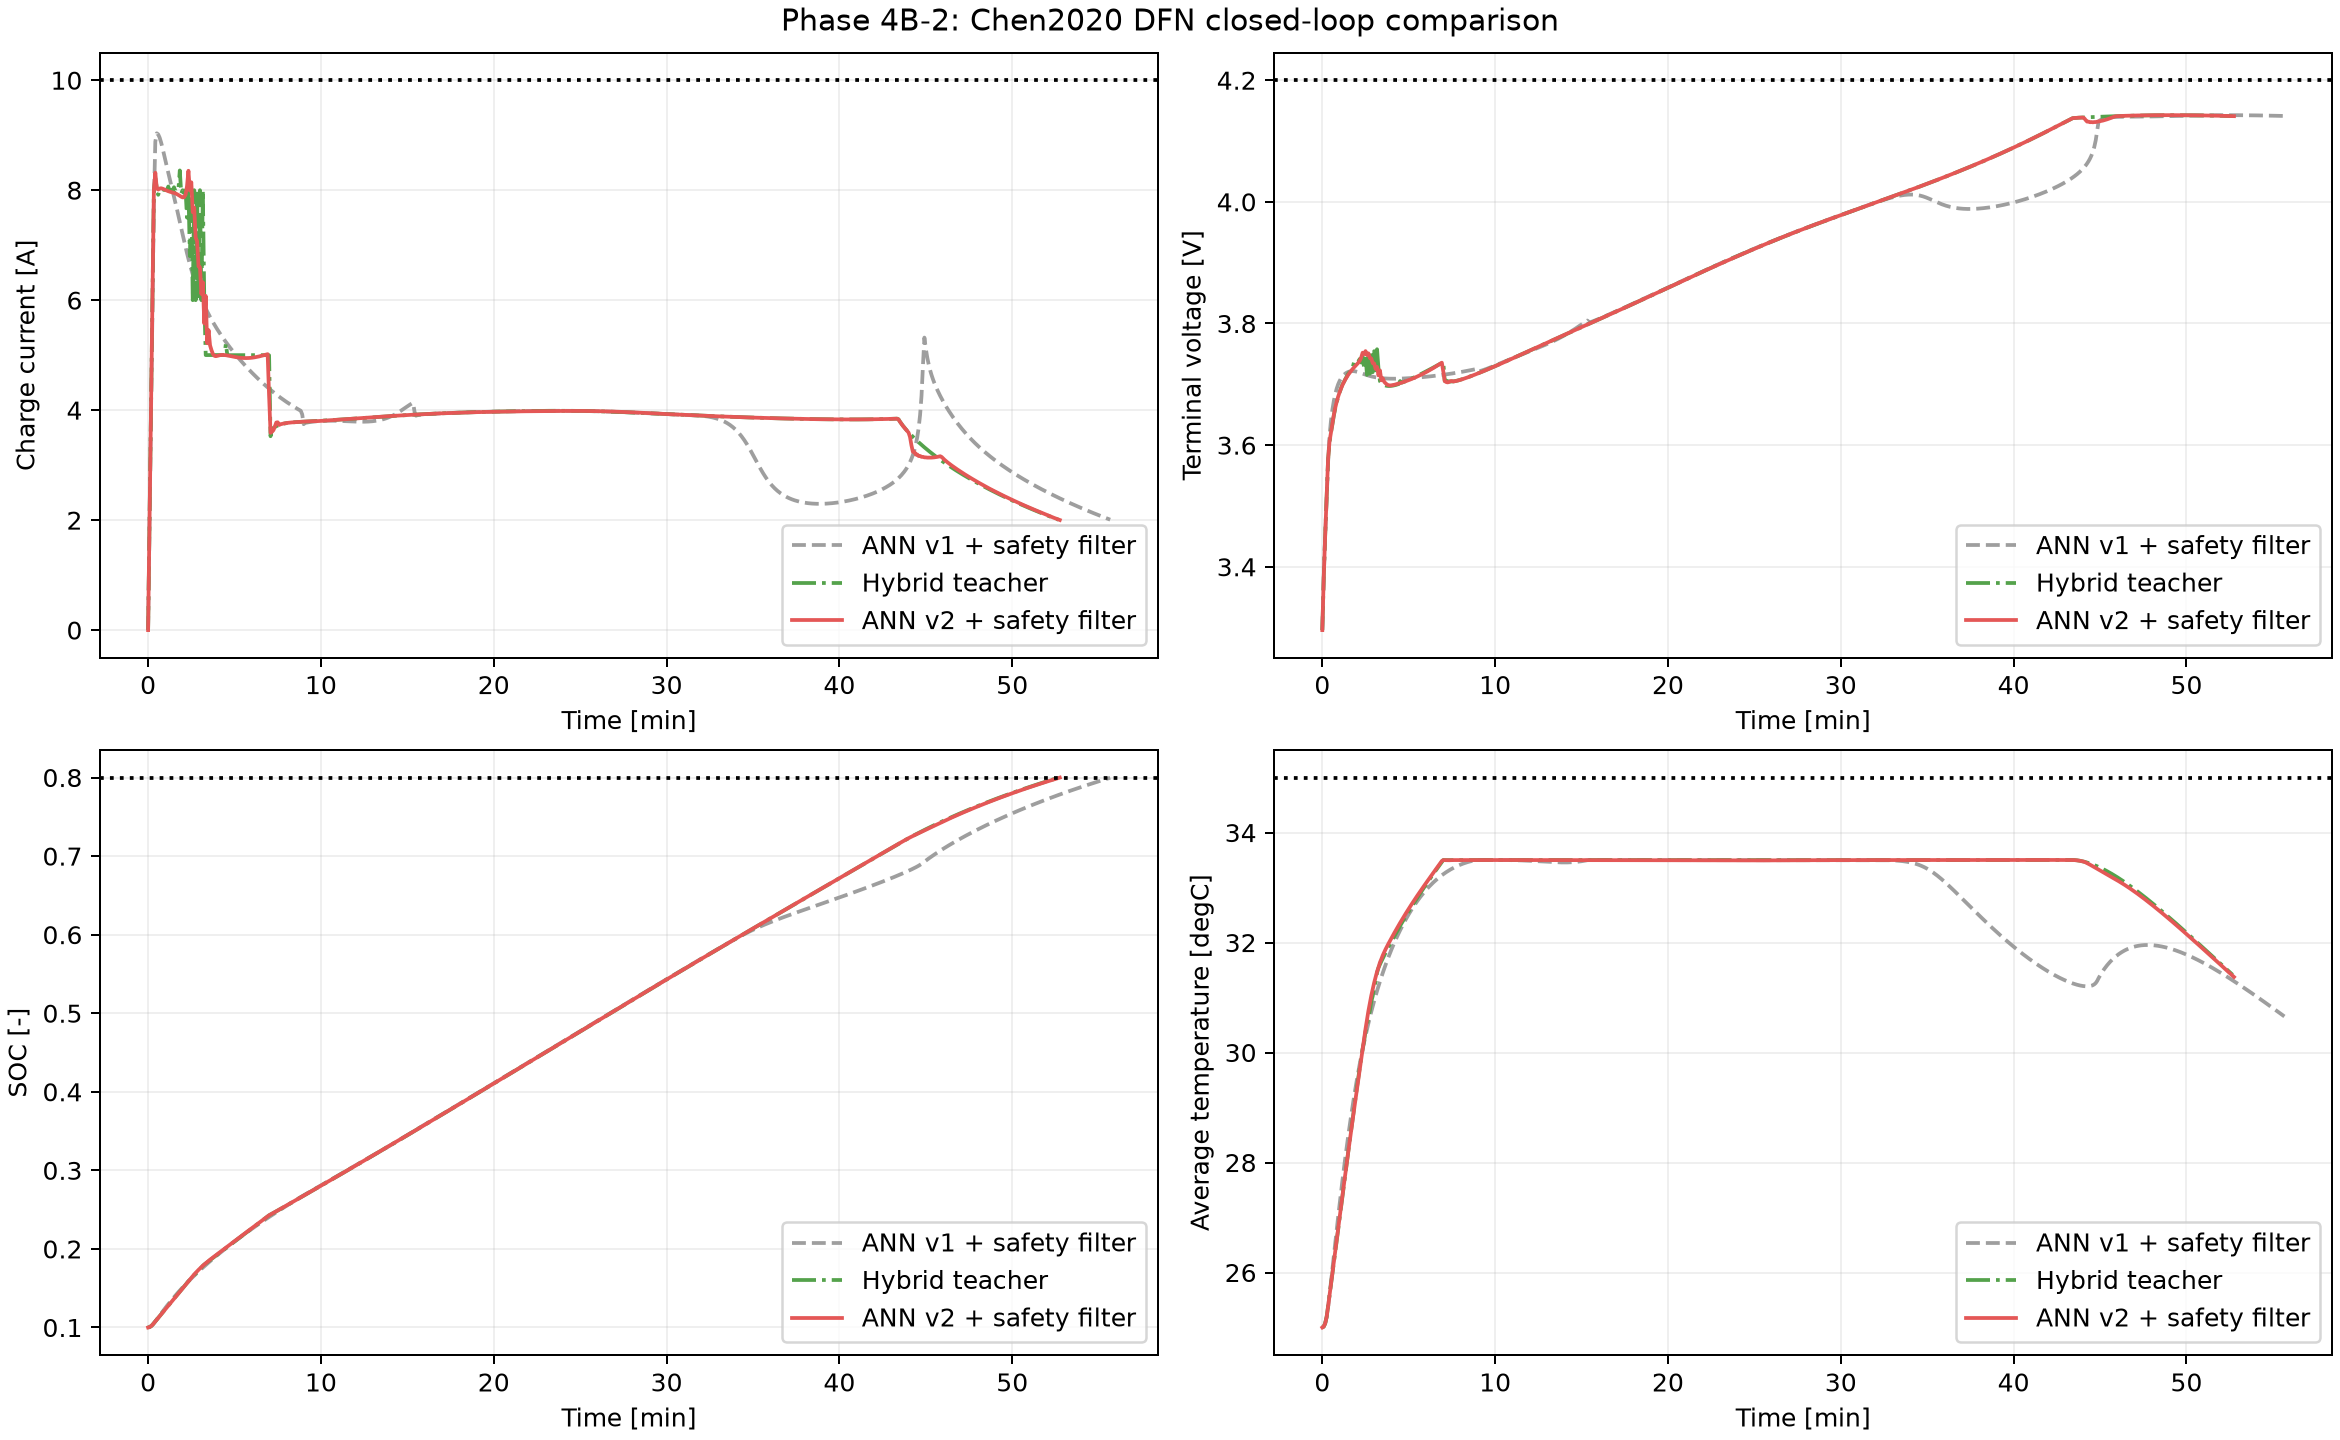

,result
charge time [min],52.7500
teacher time gap [%],0.1582
material interventions [%],1.5798
mean filter correction [A],0.0166
p95 filter correction [A],0.0442
maximum voltage [V],4.1426
maximum average temperature [°C],33.5024
inference speedup,12611.0857


In [6]:
display(comparison.round(4))
display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / "phase4b2_ann_v2_dfn_comparison.png")))

dfn = metrics["ann_v2_dfn_closed_loop"]
closed_loop = pd.Series({
    "charge time [min]": dfn["charge_time_min"],
    "teacher time gap [%]": 100 * metrics["dfn_time_gap_fraction_from_hybrid_teacher"],
    "material interventions [%]": 100 * dfn["material_safety_filter_intervention_fraction"],
    "mean filter correction [A]": dfn["mean_safety_filter_correction_a"],
    "p95 filter correction [A]": dfn["p95_safety_filter_correction_a"],
    "maximum voltage [V]": dfn["maximum_voltage_v"],
    "maximum average temperature [°C]": dfn["maximum_temperature_c"],
    "inference speedup": metrics["inference_speedup_over_hybrid_mpc"],
})
display(closed_loop.to_frame("result").round(4))

ANN v2用52.75 min完成充电，只比教师慢5 s，比ANN v1快2.92 min。虽然二元过滤介入仍约40.8%，其中大多数是很小的边界修正；超过0.1 A的实质介入只有1.58%，平均修正0.0166 A。这个区别正是本阶段同时报告频率和幅度的原因。

## 全部验收闸门

In [7]:
display(pd.Series(metrics["checks"], name="passed").to_frame())
display(pd.Series({
    "Phase 4B-2 passed": metrics["success"],
    "Ready for robustness validation": metrics["ready_for_robustness_validation"],
    "Standalone ANN ready": metrics["standalone_ann_ready"],
}, name="result").to_frame())

,passed
active_dataset,True
test_mae,True
test_rmse,True
numpy_model_round_trip,True
reduced_closed_loop,True
dfn_closed_loop,True
material_intervention_fraction,True
mean_filter_correction,True
dfn_time_gap_from_hybrid_teacher,True
improvement_over_phase4a,True


,result
Phase 4B-2 passed,True
Ready for robustness validation,True
Standalone ANN ready,False


## 结论与下一步

- 主动数据聚合、两轮DAgger和小幅容量增加使ANN v2通过当前单温度仿真闸门；
- 安全过滤器仍必须保留，`standalone_ann_ready` 仍为 `False`；
- 下一阶段应进入鲁棒性验证：多温度、容量/内阻扰动、老化、SOC与温度观测噪声，以及极化状态观测器误差；
- 当前平均温度模型仍不能证明极耳或局部热点安全。